In [357]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

api = wandb.Api(
    api_key="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",
    timeout=60
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=10,
    # limit to 10:
    lazy=False,
)

In [358]:
rows = []
for run in runs:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    summary = attrs.get("summaryMetrics") or {}

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_way": params.get("n_way"),
        "n_query": params.get("n_query"),
        "zero_shot": params.get("zero_shot"),
        "test_accuracy": summary.get("test_accuracy"),
        "train_accuracy": summary.get("train_accuracy"),
        "test_f1": summary.get("test_f1"),
        "test_roc_auc": summary.get("test_roc_auc"),
        "created_at": attrs.get("createdAt"),
        'steps': attrs['historyKeys']['keys'].get('_step', {}).get('typeCounts', [{}])[0].get('count', np.nan),
        'tags': attrs.get("tags", []),
    })
    
    


In [387]:
df = pd.DataFrame(rows)
df["train1_dataset"] = df["pretrained_model_run"].str.extract(r"train1_(ukr_rus_twitter|midterm|covid19_twitter|election20202|covid_political|ukr_rus_suspended)_")
df["train1_task"] = df["pretrained_model_run"].str.extract(r"train1_.+?_(nm|pl|lp)_")
df["eval1_task"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df['created_at'] = pd.to_datetime(df['created_at'])
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# df['is_eval'] = df['display_name'].str.contains(r"eval")
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']
df['trained_on_display_name'] = df.pretrained_model_run.str.split('/').str[1]
df['month/day'] = df['created_at'].dt.month.astype(str) + '/' + df['created_at'].dt.day.astype(str)
df = df.sort_values('created_at', ascending=False)
d = {
    'trained_on_n_way': 'n_way',
    'trained_on_n_query': 'n_query',
    'trained_on_n_shots': 'n_shots',
    'trained_on_steps': 'steps',
}
mask = df['trained_on_display_name'].isin(df['display_name'])
existing_trained_on_display_names = df.trained_on_display_name[mask]
dname2stats = df.set_index('display_name').loc[existing_trained_on_display_names][list(d.values())]
for col, stat in d.items():
    df[col] = df.trained_on_display_name.map(dname2stats[stat].to_dict())
df__ = df.copy()

# df = df__[df__.tags.astype(str).str.contains('social_llm_v4', regex=False, na=False)]

t1 = df__[df__.tags.astype(str).str.contains('v4')].created_at[:2].tolist()

start, end = min(t1), max(t1)

mask = df__.created_at.between(start, end)

df__.loc[mask, 'tags'] = df__.loc[mask, 'tags'].apply(lambda x: x + ['social_llm_v4'])

df = df__[df__.tags.astype(str).str.contains('social_llm_v4', regex=False, na=False)]

In [390]:
unique_on = ['train1_dataset', 'train1_task', 'eval1_dataset', 'eval1_task', 'n_shots']

In [391]:
df["seq_id"] = df.train1_dataset.fillna("NA").astype(str) + "+" + df.train1_task.fillna("NA").astype(str) + "|" + df.eval1_dataset.fillna("NA").astype(str) + "+" + df.eval1_task.fillna("NA").astype(str) + "(" + df.n_shots.astype(str) + ")"

In [402]:
# df['train_id'] = df.seq_id.str.split(">").str[1]
# df['train_id']
# df.groupby('seq_id').n_shots.value_counts()
# df.groupby(unique_on).test_roc_auc.value_counts()
df['auc_rounded'] = df.test_roc_auc.round(4)
df = df.sort_values('created_at', ascending=False).drop_duplicates(unique_on, keep='first')

In [364]:
# df.groupby(unique_on)['test_roc_auc'].value_counts()
for dataset1 in df.train1_dataset.unique():
    for task1 in df.train1_task.unique():
        for dataset2 in df.train1_dataset.unique():
            for task2 in df.train1_task.unique():
                for n_shots in df.n_shots.unique():
                    id = f'{dataset1}+{task1}|{dataset2}+{task2}({n_shots})'
                    if task1 == 'pl':
                        continue
                    if dataset1 == dataset2 and task1 == task2:
                        continue
                    if df.seq_id.eq(id).sum() != 1:
                        # print(id)
                        pass

In [365]:
unique_on

['train1_dataset', 'train1_task', 'eval1_dataset', 'eval1_task', 'n_shots']

In [405]:
df['train_id'] = df.train1_dataset.fillna("NA").astype(str) + "+" + df.train1_task.fillna("NA").astype(str)
df['eval_id'] = df.eval1_dataset.fillna("NA").astype(str) + "+" + df.eval1_task.fillna("NA").astype(str)

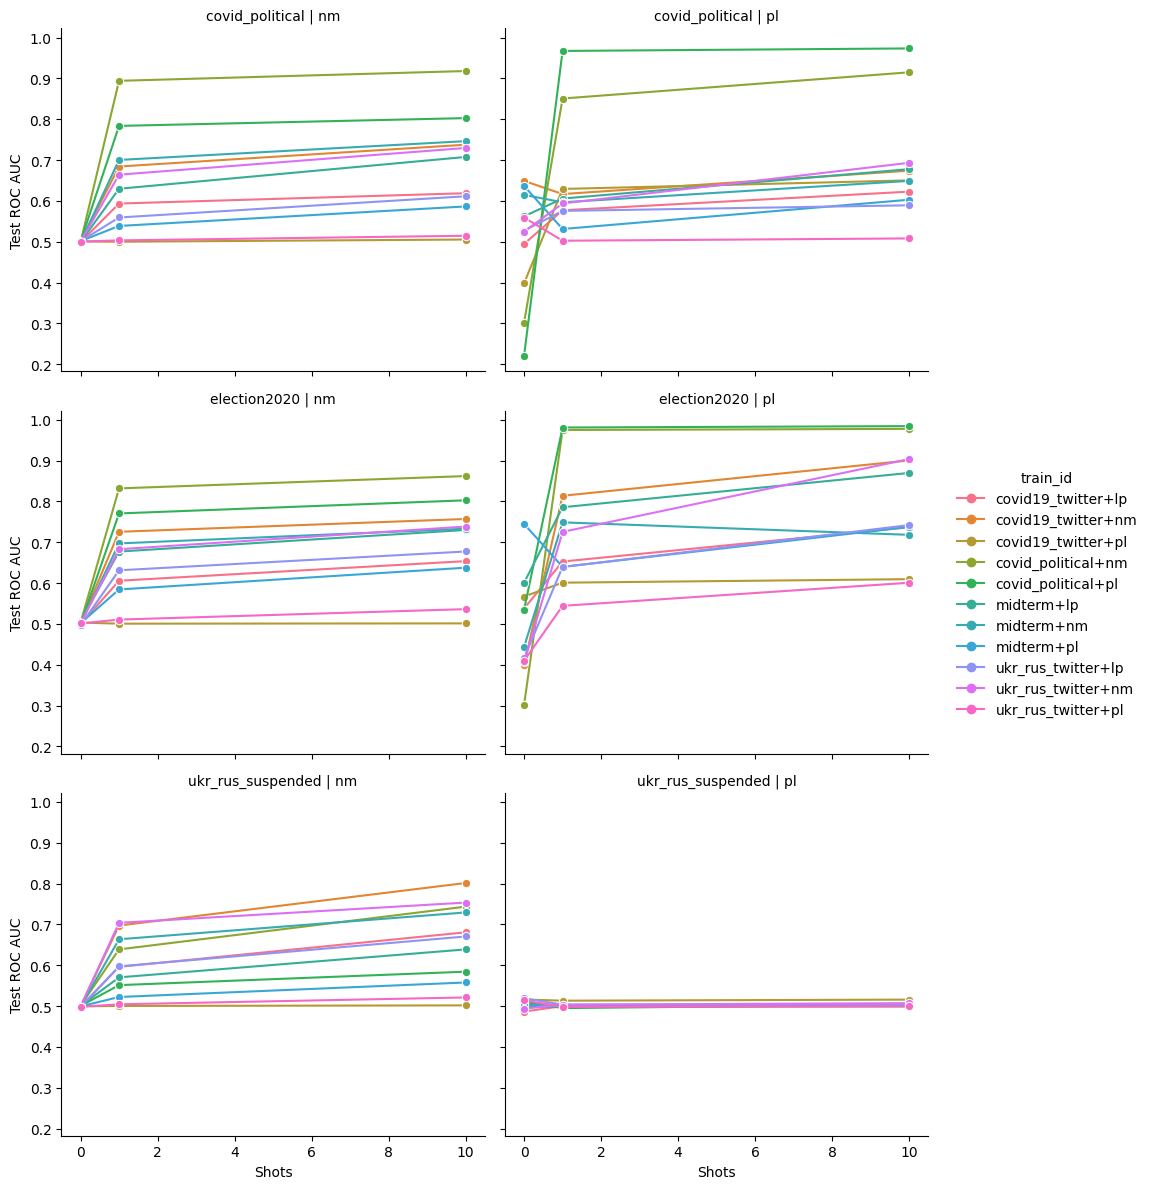

In [406]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# assuming df already exists
# cols:
# ['train_id', 'eval1_dataset', 'eval1_task', 'n_shots', 'test_roc_auc']

# optional: sort x-axis nicely
df = df.sort_values(["eval1_dataset", "eval1_task", "train_id", "n_shots"])

g = sns.relplot(
    data=df,
    x="n_shots",
    y="test_roc_auc",
    hue="train_id",              # each train_id gets its own color
    row="eval1_dataset",         # rows = dataset
    col="eval1_task",            # cols = task
    kind="line",                 # line plot across shots
    marker="o",
    height=4,
    aspect=1.2,
    facet_kws={"sharey": True, "sharex": True}
)

g.set_axis_labels("Shots", "Test ROC AUC")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.tight_layout()

plt.show()

In [368]:
# t.eval1_dataset.unique()
# ['covid_political', 'covid19_twitter', 'ukr_rus_twitter', 'midterm']
tasks = ['pl', 'nm', 'lp',]
datasets = ['election2020','covid_political','ukr_rus_suspended','ukr_rus_twitter','midterm','covid19_twitter']

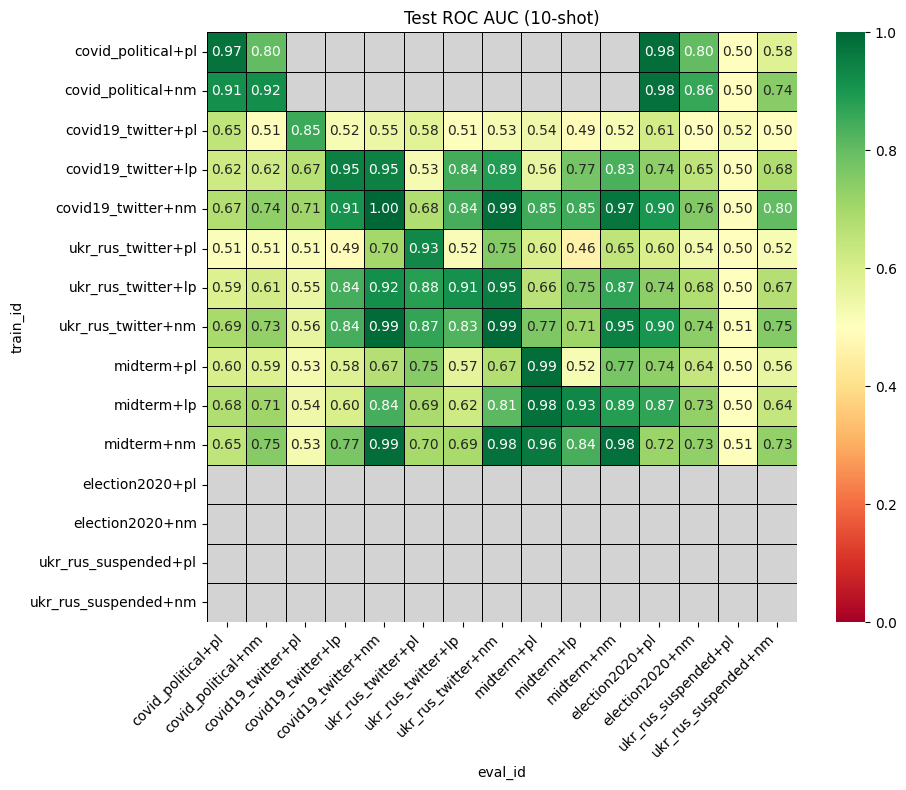

In [417]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap



import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# filter
t = df__.drop_duplicates(unique_on)

t['train_id'] = t.train1_dataset.fillna("NA").astype(str) + "+" + t.train1_task.fillna("NA").astype(str)
t['eval_id'] = t.eval1_dataset.fillna("NA").astype(str) + "+" + t.eval1_task.fillna("NA").astype(str)

t = t[t.train1_dataset.isin(datasets) & t.eval1_dataset.isin(datasets) & t.train1_task.isin(tasks) & t.eval1_task.isin(tasks)]

df_10 = t[t["n_shots"] == 10].copy()

# pivot observed values
mat = df_10.pivot_table(
    index="train_id",
    columns="eval_id",
    values="test_roc_auc",
    aggfunc="mean"
)

# union while preserving first occurrence order
all_ids = pd.unique(
    pd.concat([
        df_10["train_id"],
        df_10["eval_id"]
    ])
)

mat = mat.reindex(index=all_ids, columns=all_ids)


cmap = sns.color_palette("RdYlGn", as_cmap=True)
cmap.set_bad("lightgrey")  # missing values

plt.figure(figsize=(10, 8))
sns.heatmap(
    mat,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=0,
    vmax=1,
    linewidths=0.5,      # border thickness
    linecolor="black",   # border color
    square=True          # optional: make cells square
)

plt.xlabel("eval_id")
plt.ylabel("train_id")
plt.title("Test ROC AUC (10-shot)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [408]:
mat.sub(mat.max(1),0).mean(1).sort_values(key=abs)

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_62796/2742782186.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of max will be keyword-only.
  mat.sub(mat.max(1),0).mean(1).sort_values(key=abs)
/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_62796/2742782186.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  mat.sub(mat.max(1),0).mean(1).sort_values(key=abs)


train_id
covid_political+nm     -0.158485
covid19_twitter+nm     -0.186869
ukr_rus_twitter+nm     -0.203194
covid_political+pl     -0.209291
ukr_rus_twitter+lp     -0.211840
midterm+nm             -0.219655
covid19_twitter+lp     -0.229609
midterm+lp             -0.246085
covid19_twitter+pl     -0.293864
midterm+pl             -0.342737
ukr_rus_twitter+pl     -0.344570
election2020+pl              NaN
election2020+nm              NaN
ukr_rus_suspended+pl         NaN
ukr_rus_suspended+nm         NaN
dtype: float64

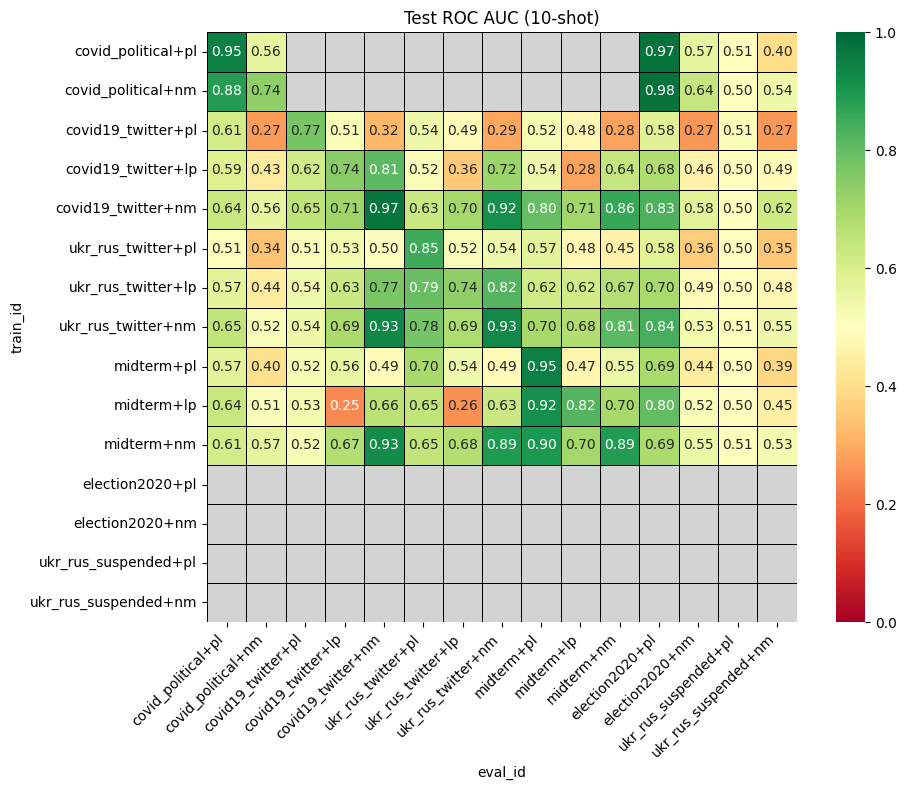

In [416]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap



import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# filter
t = df__.drop_duplicates(unique_on)

t['train_id'] = t.train1_dataset.fillna("NA").astype(str) + "+" + t.train1_task.fillna("NA").astype(str)
t['eval_id'] = t.eval1_dataset.fillna("NA").astype(str) + "+" + t.eval1_task.fillna("NA").astype(str)

t = t[t.train1_dataset.isin(datasets) & t.eval1_dataset.isin(datasets) & t.train1_task.isin(tasks) & t.eval1_task.isin(tasks)]

df_10 = t[t["n_shots"] == 10].copy()

# pivot observed values
mat = df_10.pivot_table(
    index="train_id",
    columns="eval_id",
    values="test_f1",
    aggfunc="mean"
)

# union while preserving first occurrence order
all_ids = pd.unique(
    pd.concat([
        df_10["train_id"],
        df_10["eval_id"]
    ])
)

mat = mat.reindex(index=all_ids, columns=all_ids)


cmap = sns.color_palette("RdYlGn", as_cmap=True)
cmap.set_bad("lightgrey")  # missing values

plt.figure(figsize=(10, 8))
sns.heatmap(
    mat,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=0,
    vmax=1,
    linewidths=0.5,      # border thickness
    linecolor="black",   # border color
    square=True          # optional: make cells square
)

plt.xlabel("eval_id")
plt.ylabel("train_id")
plt.title("Test ROC AUC (10-shot)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [411]:
t['seq_id'] = t.train_id + "|" + t.eval_id
# t[t.seq_id.str.contains('covid_political\+')].seq_id

In [431]:
df[df.n_shots.eq(10) & df.eval1_task.eq('pl')].set_index('seq_id').sort_values('test_f1', ascending=False).drop_duplicates('eval_id').test_f1

seq_id
covid_political+nm|election2020+pl(10.0)         0.975893
covid_political+pl|covid_political+pl(10.0)      0.946805
covid19_twitter+pl|ukr_rus_suspended+pl(10.0)    0.512982
Name: test_f1, dtype: float64